# **Events Processing in CrewAI**

#+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

# **Part-1: Understanding Event Processing in CrewAI**

## Overview

### CrewAI provides a powerful event system that allows you to listen for and react to various events that occur during the execution of your Crew.

### This feature enables you to build **custom integrations**, **monitoring solutions**, **logging systems**, or any other functionality that **needs to be triggered based on CrewAI’s internal events**.

## How It Works

### CrewAI uses an **event bus architecture** to **emit events** throughout the **execution lifecycle**.

### The event system is built on the following components:

### > **CrewAIEventsBus**: A singleton event bus that manages event registration and emission

### > **BaseEvent**: Base class for all events in the system

### > **BaseEventListener**: Abstract base class for creating custom event listeners

### When specific actions occur in CrewAI (like a Crew starting execution, an Agent completing a task, or a tool being used), the system emits corresponding events.

## You can **register handlers** for these events to **execute custom code** when they occur.

## Install necessary Libraries

In [ ]:
!pip install -q crewai crewai_tools

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 kB 7.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.8/195.8 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.4/40.4 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 836.4/836.4 kB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.9/19.9 MB 67.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.5/252.5 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4

In [ ]:
import crewai
import crewai_tools
print(crewai.__version__)
print(crewai_tools.__version__)

1.15.17
1.15.17


## Creating a Custom Event Listener

To create a custom event listener, you need to:

> **Create a class** that inherits from **BaseEventListener**

> **Implement** the **setup_listeners** method

> **Register handlers** for the events you’re interested in

> **Create an instance** of your listener in the appropriate file

Here’s a simple example of a custom event listener class:

In [ ]:
from crewai.events import (
    CrewKickoffStartedEvent,
    CrewKickoffCompletedEvent,
    AgentExecutionCompletedEvent,
)

from crewai.events import BaseEventListener

# Custom class that inherits from BaseEventListener
class MyCustomListener(BaseEventListener):
    def __init__(self):
        super().__init__()

    # Implement setup_listeners
    def setup_listeners(self, crewai_event_bus):

        # Register handler
        @crewai_event_bus.on(CrewKickoffStartedEvent)
        def on_crew_started(source, event):
            print(f"Crew '{event.crew_name}' has started execution!")

        # Register handler
        @crewai_event_bus.on(CrewKickoffCompletedEvent)
        def on_crew_completed(source, event):
            print(f"Crew '{event.crew_name}' has completed execution!")
            print(f"Output: {event.output}")

        # Register handler
        @crewai_event_bus.on(AgentExecutionCompletedEvent)
        def on_agent_execution_completed(source, event):
            print(f"Agent '{event.agent.role}' completed task")
            print(f"Output: {event.output}")

In [ ]:
# Instantiate
custom_event_listener = MyCustomListener()

# Set API Keys

In [ ]:
from google.colab import userdata
import os
os.environ["SERPER_API_KEY"] = userdata.get('SERPER_API_KEY')
os.environ["OPENROUTER_API_KEY"] = userdata.get('OPENROUTER_API_KEY')

## Import Dependencies

In [ ]:
from crewai import Agent, Task, Crew, LLM

## Create the LLM Object

In [ ]:
# OPENROUTER hosted LLMs
llm = LLM(
    model="openrouter/openai/gpt-oss-120b",
    base_url="https://openrouter.ai/api/v1",
    api_key=os.getenv("OPENROUTER_API_KEY"),
)


## Define a Tool

In [ ]:
from crewai_tools import SerperDevTool
search_tool = SerperDevTool()

# Define Agents

In [ ]:
ai_assistant = Agent(
    role="AI Assistant",
    goal="""A helpful AI assistant to respond to user queries {query}""",
    backstory="""You are a helpful AI assistant who provides answers to user queries.""",
    llm=llm,
    tools=[search_tool],
    verbose=True
)

# Define Tasks

In [ ]:
task = Task(
  description="""A question asked by the user {query}""",
  expected_output="A suitable response to user query.",
  agent = ai_assistant
)

## Define Crew

In [ ]:
# Define Crew (Orchestration Layer)
crew = Crew(
  agents=[ai_assistant],
  tasks=[task],
  verbose=True
)

## Execute the Crew

In [ ]:
result = await crew.kickoff_async(
    {"query":"Waterlogging in Gurugram ?"}
)
result

Crew 'crew' has started execution!


╭─────────────────────────────────────────── 🚀 Crew Execution Started ───────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Started                                                                                         │
│  Name: crew                                                                                                     │
│  ID: 30a77568-e3d9-454d-887d-3aa578b7a537                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 📋 Task Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Started                                                                                                   │
│  Name: A question asked by the user Waterlogging in Gurugram ?                                                  │
│  ID: 1dab1a27-ec0d-4745-a588-51d0f49c7e4b                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: AI Assistant                                                                                            │
│                                                                                                                 │
│  Task: A question asked by the user Waterlogging in Gurugram ?                                                  │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────── 🔧 Tool Execution Started (#34) ────────────────────────────────────────╮
│                                                                                                                 │
│  Tool: search_the_internet_with_serper                                                                          │
│  Args: {'search_query': 'waterlogging Gurugram recent incidents measures'}                                      │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

Agent 'AI Assistant' completed task
Output: - **Root causes** – Gurugram’s flat terrain, rapid urban expansion, encroachment of natural ponds and an undersized, poorly‑maintained storm‑water drainage network (many drains are blocked or missing) make rainwater accumulate on roads and in low‑lying areas.  

- **Recent incidents** – In the last monsoon season the city received up to 115 mm of rain in 33 hours (and 133 mm on another day), leaving major thoroughfares such as IFFCO Chowk, Sector 14 and the road beneath the Metro station completely submerged, causing traffic jams and commuters wading through water.  

- **Impact on the city** – Water‑logging disrupts traffic, damages vehicles and infrastructure, creates health‑hazardous standing water, leads to loss of productivity and imposes extra costs on businesses and municipal services.  

- **Steps already taken** – The municipal corporation has issued work orders to clean and enlarge existing drains, launched the “Water‑Logging‑Free G

╭────────────────────────────────────────────── 📋 Task Completion ───────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Completed                                                                                                 │
│  Name: A question asked by the user Waterlogging in Gurugram ?                                                  │
│  Agent: AI Assistant                                                                                            │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── Crew Completion ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Completed                                                                                       │
│  Name: crew                                                                                                     │
│  ID: 30a77568-e3d9-454d-887d-3aa578b7a537                                                                       │
│  Final Output: - **Root causes** – Gurugram’s flat terrain, rapid urban expansion, encroachment of natural      │
│  ponds and an undersized, poorly‑maintained storm‑water drainage network (many drains are blocked or missing)   │
│  make rainwater accumulate on roads and in low‑lying areas.                                                     │
│                                                                                                                 │
│  - **Recent incidents** – In the last monsoon season the city received up to 115 mm of rain in 33 hours (and    │
│  133 mm on another day), leaving major thoroughfares such as IFFCO Chowk, Sector 14 and the road beneath the    │
│  Metro station completely submerged, causing traffic jams and commuters wading through water.                   │
│                                                                                                                 │
│  - **Impact on the city** – Water‑logging disrupts traffic, damages vehicles and infrastructure, creates        │
│  health‑hazardous standing water, leads to loss of productivity and imposes extra costs on businesses and       │
│  municipal services.                                                                                            │
│                                                                                                                 │
│  - **Steps already taken** – The municipal corporation has issued work orders to clean and enlarge existing     │
│  drains, launched the “Water‑Logging‑Free Gurugram” initiative (storm‑water audits, recharge wells, rain‑water  │
│  harvesting, community clean‑up drives) and is installing additional soak‑away pits and bioswales in            │
│  vulnerable zones.                                                                                              │
│                                                                                                                 │
│  - **Suggested long‑term solutions** – Expand and upgrade the storm‑water network to meet the city’s            │
│  population load, enforce strict zoning to prevent pond encroachment, adopt permeable pavements and green       │
│  infrastructure (bioswales, retention ponds), mandate rain‑water harvesting in new developments, and ensure     │
│  regular maintenance and public awareness campaigns to keep drains clear.                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

CrewOutput(raw='- **Root causes** – Gurugram’s flat terrain, rapid urban expansion, encroachment of natural ponds and an undersized, poorly‑maintained storm‑water drainage network (many drains are blocked or missing) make rainwater accumulate on roads and in low‑lying areas.  \n\n- **Recent incidents** – In the last monsoon season the city received up to\u202f115\u202fmm of rain in 33\u202fhours (and 133\u202fmm on another day), leaving major thoroughfares such as IFFCO Chowk, Sector\u202f14 and the road beneath the Metro station completely submerged, causing traffic jams and commuters wading through water.  \n\n- **Impact on the city** – Water‑logging disrupts traffic, damages vehicles and infrastructure, creates health‑hazardous standing water, leads to loss of productivity and imposes extra costs on businesses and municipal services.  \n\n- **Steps already taken** – The municipal corporation has issued work orders to clean and enlarge existing drains, launched the “Water‑Logging‑Fre



╭────────────────────────── Tracing Preference Saved ──────────────────────────╮
│                                                                              │
│  Info: Tracing has been disabled.                                            │
│                                                                              │
│  Your preference has been saved. Future Crew/Flow executions will not        │
│  collect traces.                                                             │
│                                                                              │
│  To enable tracing later, do any one of these:                               │
│  • Set tracing=True in your Crew/Flow code                                   │
│  • Set CREWAI_TRACING_ENABLED=true in your project's .env file               │
│  • Run: crewai traces enable                                                 │
│                                                                              │
╰─────────────────────────

## In the above output, check the messages emitted by the custom event listeners.

## Available Event Types

CrewAI provides a wide range of events that you can listen for:

## Crew Events

**CrewKickoffStartedEvent**: Emitted when a Crew starts execution

**CrewKickoffCompletedEvent**: Emitted when a Crew completes execution

**CrewKickoffFailedEvent**: Emitted when a Crew fails to complete execution

**CrewTestStartedEvent**: Emitted when a Crew starts testing

**CrewTestCompletedEvent**: Emitted when a Crew completes testing

**CrewTestFailedEvent**: Emitted when a Crew fails to complete testing

**CrewTrainStartedEvent**: Emitted when a Crew starts training

**CrewTrainCompletedEvent**: Emitted when a Crew completes training

**CrewTrainFailedEvent**: Emitted when a Crew fails to complete training

**CrewTestResultEvent**: Emitted when a Crew test result is available. Contains the quality score, execution duration, and model used.


## Agent Events

**AgentExecutionStartedEvent**: Emitted when an Agent starts executing a task

**AgentExecutionCompletedEvent**: Emitted when an Agent completes executing a task

**AgentExecutionErrorEvent**: Emitted when an Agent encounters an error during execution

**LiteAgentExecutionStartedEvent**: Emitted when a LiteAgent starts executing. Contains the agent
info, tools, and messages.

**LiteAgentExecutionCompletedEvent**: Emitted when a LiteAgent completes execution. Contains the agent info and output.

**LiteAgentExecutionErrorEvent**: Emitted when a LiteAgent encounters an error during execution. Contains the agent info and error message.

**AgentEvaluationStartedEvent**: Emitted when an agent evaluation starts. Contains the agent ID, agent role, optional task ID, and iteration number.

**AgentEvaluationCompletedEvent**: Emitted when an agent evaluation completes. Contains the agent ID, agent role, optional task ID, iteration number, metric category, and score.

**AgentEvaluationFailedEvent**: Emitted when an agent evaluation fails. Contains the agent ID, agent role, optional task ID, iteration number, and error message.


## Task Events

**TaskStartedEvent**: Emitted when a Task starts execution

**TaskCompletedEvent**: Emitted when a Task completes execution

**TaskFailedEvent**: Emitted when a Task fails to complete execution

**TaskEvaluationEvent**: Emitted when a Task is evaluated


## Tool Usage Events

**ToolUsageStartedEvent**: Emitted when a tool execution is started

**ToolUsageFinishedEvent**: Emitted when a tool execution is completed

**ToolUsageErrorEvent**: Emitted when a tool execution encounters an error

**ToolValidateInputErrorEvent**: Emitted when a tool input validation encounters an error

**ToolExecutionErrorEvent**: Emitted when a tool execution encounters an error

**ToolSelectionErrorEvent**: Emitted when there’s an error selecting a tool

​

Check the complete list of events on this page:

https://docs.crewai.com/v1.15.16/en/concepts/event-listener


## Use Cases

Event listeners can be used for a variety of purposes:

> **Logging and Monitoring**: Track the execution of your Crew and log important events

> **Analytics**: Collect data about your Crew’s performance and behavior

> **Debugging**: Set up temporary listeners to debug specific issues

> **Integration**: Connect CrewAI with external systems like monitoring platforms, databases, or
notification services

> **Custom Behavior**: Trigger custom actions based on specific events
​
## Best Practices

> **Keep Handlers Light**: Event handlers should be lightweight and avoid blocking operations

> **Error Handling**: Include proper error handling in your event handlers to prevent exceptions
from affecting the main execution

> **Cleanup**: If your listener allocates resources, ensure they’re properly cleaned up

> **Selective Listening**: Only listen for events you actually need to handle

> **Testing**: Test your event listeners in isolation to ensure they behave as expected

By leveraging CrewAI’s event system, you can extend its functionality and integrate it seamlessly with your existing infrastructure.

# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

# **Part-2: CrewAI Observability Demo : An End-to-End Usecase using Event Processing**


Events we need here are **TaskCompletedEvent**, **ToolUsageFinishedEvent**, **LLMCallCompletedEvent**, **AgentExecutionCompletedEvent**, and the crew start/completion events.


The event listener will simultaneously provide four observability capabilities:

> **Execution logging** — crew/agent/task lifecycle

> **Tool monitoring** — tool input, output, duration, failures

> **Task validation** — validate structured task output when a task completes

> **LLM analytics** — token usage, estimated cost, number of calls

CrewAI explicitly recommends keeping event handlers lightweight and registering the listener instance so it remains active during execution.

## Define a Custom Tool

For the time being, this tool will return some dummy data.
This is deliberately deterministic so the example can run without requiring another external API.
The important point is that the tool itself does not perform logging.

The event listener will observe it. That's an important architectural distinction.

In [ ]:
from crewai.tools import BaseTool
from pydantic import BaseModel, Field


class CompanyMetricsInput(BaseModel):
    company: str = Field(..., description="Company name")


class CompanyMetricsTool(BaseTool):
    name: str = "company_metrics_tool"

    description: str = (
        "Retrieves basic financial metrics for a company. "
        "Use this tool when financial data is required."
    )

    args_schema: type[BaseModel] = CompanyMetricsInput

    def _run(self, company: str) -> str:

        # In a real application this could call:
        # Yahoo Finance / Alpha Vantage / Bloomberg / NSE API etc.

        data = {
            "company": company,
            "revenue_growth": 12.4,
            "profit_growth": 15.8,
            "pe_ratio": 24.7,
            "debt_to_equity": 0.42,
            "roe": 18.6,
        }

        return str(data)

## Define Custom Event Listeners

This is the core of the example.

In [ ]:
import json
import time
from pathlib import Path
from datetime import datetime

from crewai.events import (
    BaseEventListener,

    CrewKickoffStartedEvent,
    CrewKickoffCompletedEvent,
    CrewKickoffFailedEvent,

    AgentExecutionStartedEvent,
    AgentExecutionCompletedEvent,
    AgentExecutionErrorEvent,

    TaskStartedEvent,
    TaskCompletedEvent,
    TaskFailedEvent,

    ToolUsageStartedEvent,
    ToolUsageFinishedEvent,
    ToolUsageErrorEvent,

    LLMCallStartedEvent,
    LLMCallCompletedEvent,
    LLMCallFailedEvent,
)


LOG_DIR = Path("logs")
LOG_DIR.mkdir(exist_ok=True)


def write_jsonl(filename, data):

    path = LOG_DIR / filename

    with path.open("a", encoding="utf-8") as f:
        f.write(json.dumps(data, default=str) + "\n")


class ObservabilityListener(BaseEventListener):

    def __init__(self):

        super().__init__()

        self.crew_start_time = None
        self.task_start_times = {}
        self.tool_start_times = {}

        self.total_input_tokens = 0
        self.total_output_tokens = 0
        self.total_tokens = 0
        self.total_cost = 0.0
        self.llm_calls = 0
        self.tool_calls = 0

    # ---------------------------------------------------------
    # REGISTER EVENT HANDLERS
    # ---------------------------------------------------------

    def setup_listeners(self, crewai_event_bus):

        # =====================================================
        # CREW EVENTS
        # =====================================================

        @crewai_event_bus.on(CrewKickoffStartedEvent)
        def crew_started(source, event):

            self.crew_start_time = time.perf_counter()

            print("\n======================================")
            print("CREW STARTED")
            print("======================================")

            write_jsonl(
                "events.jsonl",
                {
                    "timestamp": datetime.utcnow().isoformat(),
                    "event": "crew_started",
                    "crew": event.crew_name,
                },
            )


        @crewai_event_bus.on(CrewKickoffCompletedEvent)
        def crew_completed(source, event):

            duration = None

            if self.crew_start_time:
                duration = time.perf_counter() - self.crew_start_time

            print("\n======================================")
            print("CREW COMPLETED")
            print(f"Duration: {duration:.2f}s")
            print("======================================")

            print("\nANALYTICS")
            print("----------------------")
            print(f"LLM calls:       {self.llm_calls}")
            print(f"Input tokens:    {self.total_input_tokens}")
            print(f"Output tokens:   {self.total_output_tokens}")
            print(f"Total tokens:    {self.total_tokens}")
            print(f"Estimated cost:  ${self.total_cost:.6f}")
            print(f"Tool calls:      {self.tool_calls}")

            write_jsonl(
                "usage.jsonl",
                {
                    "timestamp": datetime.utcnow().isoformat(),
                    "event": "crew_completed",
                    "duration_seconds": duration,
                    "llm_calls": self.llm_calls,
                    "input_tokens": self.total_input_tokens,
                    "output_tokens": self.total_output_tokens,
                    "total_tokens": self.total_tokens,
                    "estimated_cost": self.total_cost,
                    "tool_calls": self.tool_calls,
                },
            )


        @crewai_event_bus.on(CrewKickoffFailedEvent)
        def crew_failed(source, event):

            print("\nCREW FAILED")

            write_jsonl(
                "events.jsonl",
                {
                    "timestamp": datetime.utcnow().isoformat(),
                    "event": "crew_failed",
                    "error": str(event),
                },
            )


        # =====================================================
        # AGENT EVENTS
        # =====================================================

        @crewai_event_bus.on(AgentExecutionStartedEvent)
        def agent_started(source, event):

            role = event.agent.role

            print(f"\n[AGENT STARTED] {role}")

            write_jsonl(
                "events.jsonl",
                {
                    "timestamp": datetime.utcnow().isoformat(),
                    "event": "agent_started",
                    "agent": role,
                },
            )


        @crewai_event_bus.on(AgentExecutionCompletedEvent)
        def agent_completed(source, event):

            role = event.agent.role

            print(f"[AGENT COMPLETED] {role}")

            write_jsonl(
                "events.jsonl",
                {
                    "timestamp": datetime.utcnow().isoformat(),
                    "event": "agent_completed",
                    "agent": role,
                    "output": str(event.output),
                },
            )


        @crewai_event_bus.on(AgentExecutionErrorEvent)
        def agent_failed(source, event):

            role = event.agent.role

            print(f"[AGENT ERROR] {role}")

            write_jsonl(
                "events.jsonl",
                {
                    "timestamp": datetime.utcnow().isoformat(),
                    "event": "agent_error",
                    "agent": role,
                    "error": str(event),
                },
            )


        # =====================================================
        # TASK EVENTS
        # =====================================================

        @crewai_event_bus.on(TaskStartedEvent)
        def task_started(source, event):

            task_id = str(id(source))

            self.task_start_times[task_id] = time.perf_counter()

            print(f"\n[TASK STARTED] {source.description[:80]}...")


        @crewai_event_bus.on(TaskCompletedEvent)
        def task_completed(source, event):

            task_id = str(id(source))

            duration = None

            if task_id in self.task_start_times:

                duration = (
                    time.perf_counter()
                    - self.task_start_times[task_id]
                )

            output = event.output

            # ---------------------------------------------
            # STRUCTURED OUTPUT VALIDATION
            # ---------------------------------------------

            validation = self.validate_task_output(
                source,
                output
            )

            print("\n[TASK COMPLETED]")
            print(f"Valid structured output: {validation['valid']}")
            print(f"Duration: {duration:.2f}s")

            if not validation["valid"]:
                print(
                    "VALIDATION ERROR:",
                    validation["error"]
                )

            write_jsonl(
                "task_results.jsonl",
                {
                    "timestamp": datetime.utcnow().isoformat(),
                    "event": "task_completed",
                    "task": source.description,
                    "duration_seconds": duration,
                    "valid": validation["valid"],
                    "validation_error": validation["error"],
                    "output": str(output),
                },
            )


        @crewai_event_bus.on(TaskFailedEvent)
        def task_failed(source, event):

            print("\n[TASK FAILED]")

            write_jsonl(
                "task_results.jsonl",
                {
                    "timestamp": datetime.utcnow().isoformat(),
                    "event": "task_failed",
                    "task": source.description,
                    "error": str(event),
                },
            )


        # =====================================================
        # TOOL EVENTS
        # =====================================================

        @crewai_event_bus.on(ToolUsageStartedEvent)
        def tool_started(source, event):

            self.tool_calls += 1

            tool_name = getattr(
                event,
                "tool_name",
                "unknown_tool"
            )

            call_id = str(id(event))

            self.tool_start_times[call_id] = time.perf_counter()

            print(f"\n[TOOL STARTED] {tool_name}")

            write_jsonl(
                "tool_calls.jsonl",
                {
                    "timestamp": datetime.utcnow().isoformat(),
                    "event": "tool_started",
                    "tool": tool_name,
                    "agent": getattr(
                        event,
                        "agent_role",
                        None
                    ),
                },
            )


        @crewai_event_bus.on(ToolUsageFinishedEvent)
        def tool_finished(source, event):

            output = getattr(
                event,
                "output",
                None
            )

            tool_name = getattr(
                event,
                "tool_name",
                "unknown_tool"
            )

            duration = None

            if (
                hasattr(event, "started_at")
                and hasattr(event, "finished_at")
            ):

                duration = (
                    event.finished_at
                    - event.started_at
                ).total_seconds()

            print(f"[TOOL FINISHED] {tool_name}")
            print(f"Tool output: {output}")
            print(f"Duration: {duration}s")

            write_jsonl(
                "tool_calls.jsonl",
                {
                    "timestamp": datetime.utcnow().isoformat(),
                    "event": "tool_finished",
                    "tool": tool_name,
                    "agent": getattr(
                        event,
                        "agent_role",
                        None
                    ),
                    "duration_seconds": duration,
                    "output": str(output),
                    "from_cache": getattr(
                        event,
                        "from_cache",
                        False
                    ),
                },
            )


        @crewai_event_bus.on(ToolUsageErrorEvent)
        def tool_error(source, event):

            print("\n[TOOL ERROR]")

            write_jsonl(
                "tool_calls.jsonl",
                {
                    "timestamp": datetime.utcnow().isoformat(),
                    "event": "tool_error",
                    "error": str(event),
                },
            )


        # =====================================================
        # LLM EVENTS
        # =====================================================

        @crewai_event_bus.on(LLMCallStartedEvent)
        def llm_started(source, event):

            print("[LLM CALL] started")


        @crewai_event_bus.on(LLMCallCompletedEvent)
        def llm_completed(source, event):

            self.llm_calls += 1

            # CrewAI/provider versions can expose usage
            # differently, so we inspect common structures.

            usage = getattr(
                event,
                "usage",
                None
            )

            if usage is None:

                response = getattr(
                    event,
                    "response",
                    None
                )

                usage = getattr(
                    response,
                    "usage",
                    None
                )

            input_tokens = self.get_usage_value(
                usage,
                [
                    "prompt_tokens",
                    "input_tokens"
                ],
            )

            output_tokens = self.get_usage_value(
                usage,
                [
                    "completion_tokens",
                    "output_tokens"
                ],
            )

            total_tokens = self.get_usage_value(
                usage,
                [
                    "total_tokens"
                ],
            )

            if total_tokens == 0:

                total_tokens = (
                    input_tokens
                    + output_tokens
                )

            self.total_input_tokens += input_tokens
            self.total_output_tokens += output_tokens
            self.total_tokens += total_tokens

            # Example pricing.
            #
            # Replace these with the pricing for the
            # model/provider you actually use.

            cost = (
                input_tokens * 0.00000015
                +
                output_tokens * 0.00000060
            )

            self.total_cost += cost

            print(
                f"[LLM COMPLETED] "
                f"input={input_tokens}, "
                f"output={output_tokens}, "
                f"total={total_tokens}, "
                f"cost=${cost:.6f}"
            )

            write_jsonl(
                "usage.jsonl",
                {
                    "timestamp": datetime.utcnow().isoformat(),
                    "event": "llm_call",
                    "input_tokens": input_tokens,
                    "output_tokens": output_tokens,
                    "total_tokens": total_tokens,
                    "estimated_cost": cost,
                },
            )


        @crewai_event_bus.on(LLMCallFailedEvent)
        def llm_failed(source, event):

            print("[LLM ERROR]")

            write_jsonl(
                "usage.jsonl",
                {
                    "timestamp": datetime.utcnow().isoformat(),
                    "event": "llm_error",
                    "error": str(event),
                },
            )


    # =========================================================
    # STRUCTURED OUTPUT VALIDATION
    # =========================================================

    def validate_task_output(self, task, output):

        expected = getattr(
            task,
            "output_pydantic",
            None
        )

        # If the task does not specify structured output,
        # simply consider the output valid.

        if expected is None:

            return {
                "valid": True,
                "error": None,
            }

        try:

            # Depending on CrewAI version, the actual
            # Pydantic object may already be available.

            if hasattr(output, "pydantic"):

                result = output.pydantic

                expected.model_validate(
                    result.model_dump()
                )

            else:

                return {
                    "valid": False,
                    "error": (
                        "Expected Pydantic output "
                        "but none was produced."
                    ),
                }

            return {
                "valid": True,
                "error": None,
            }

        except Exception as e:

            return {
                "valid": False,
                "error": str(e),
            }


    @staticmethod
    def get_usage_value(usage, names):

        if usage is None:
            return 0

        for name in names:

            value = getattr(
                usage,
                name,
                None
            )

            if value is not None:
                return int(value)

            if isinstance(usage, dict):

                value = usage.get(name)

                if value is not None:
                    return int(value)

        return 0


# IMPORTANT:
# Instantiating the listener registers it with CrewAI's
# global event bus and keeps the listener alive.

observability_listener = ObservabilityListener()

There is one particularly important architectural point here.

The listener is not part of the business logic of the agents.

The agents don't know that logging, analytics, validation, etc. are happening.

They simply execute.

The event bus provides the separation:



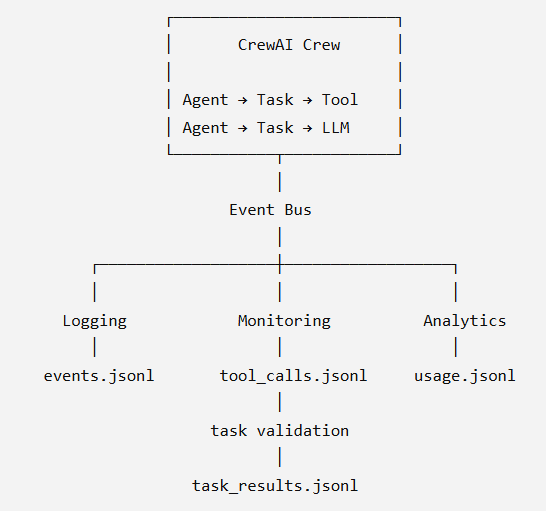

That's exactly the sort of separation event listeners are intended to provide.
CrewAI describes the event bus as a singleton that emits events across the execution lifecycle, with BaseEventListener providing the extension mechanism.

## Structured output model

Now let's make the final task produce something meaningful and machine-readable.

In [ ]:
from pydantic import BaseModel, Field

from crewai import Agent, Task, Crew, Process, LLM

# ============================================================
# STRUCTURED OUTPUT
# ============================================================

class InvestmentReport(BaseModel):

    company: str = Field(
        description="Company being analyzed"
    )

    investment_rating: str = Field(
        description="BUY, HOLD, or SELL"
    )

    confidence: float = Field(
        ge=0,
        le=1,
        description="Confidence between 0 and 1"
    )

    key_strengths: list[str]

    key_risks: list[str]

    recommendation: str


# ============================================================
# LLM
# ============================================================

# OPENROUTER hosted LLMs
from google.colab import userdata
import os
os.environ["OPENROUTER_API_KEY"] = userdata.get('OPENROUTER_API_KEY')

llm = LLM(
    model="openrouter/openai/gpt-oss-120b",
    base_url="https://openrouter.ai/api/v1",
    api_key=os.getenv("OPENROUTER_API_KEY"),
)




# ============================================================
# TOOL
# ============================================================

metrics_tool = CompanyMetricsTool()


# ============================================================
# AGENTS
# ============================================================

researcher = Agent(
    role="Market Researcher",

    goal=(
        "Research the company and collect reliable "
        "financial metrics required for investment analysis."
    ),

    backstory=(
        "You are an experienced equity research analyst "
        "who specializes in gathering structured financial data."
    ),

    tools=[metrics_tool],

    llm=llm,

    verbose=True,
)


analyst = Agent(
    role="Financial Analyst",

    goal=(
        "Analyze financial metrics and identify the "
        "company's major strengths and risks."
    ),

    backstory=(
        "You are a senior financial analyst who evaluates "
        "growth, profitability, valuation and leverage."
    ),

    llm=llm,

    verbose=True,
)


writer = Agent(
    role="Investment Report Writer",

    goal=(
        "Produce a concise investment recommendation "
        "based on the research and financial analysis."
    ),

    backstory=(
        "You are a professional investment research writer "
        "who converts analytical findings into decision-ready reports."
    ),

    llm=llm,

    verbose=True,
)


# ============================================================
# TASK 1
# ============================================================

research_task = Task(

    description="""
    Research the company {company}.

    Use the company_metrics_tool to retrieve financial metrics.

    Return the financial information clearly so that another
    analyst can use it.
    """,

    expected_output=(
        "A concise financial research summary containing "
        "the company's revenue growth, profit growth, "
        "P/E ratio, debt-to-equity ratio and ROE."
    ),

    agent=researcher,
)


# ============================================================
# TASK 2
# ============================================================

analysis_task = Task(

    description="""
    Analyze the research produced by the Market Researcher.

    Evaluate:

    1. Growth
    2. Profitability
    3. Valuation
    4. Financial leverage

    Identify at least three strengths and three risks.

    Produce a concise analytical assessment.
    """,

    expected_output=(
        "A financial analysis containing strengths, risks, "
        "valuation assessment and an overall investment view."
    ),

    agent=analyst,

    context=[research_task],
)


# ============================================================
# TASK 3
# ============================================================

report_task = Task(

    description="""
    Using the market research and financial analysis,
    prepare a final investment recommendation for {company}.

    The recommendation must contain:

    - company
    - investment_rating
    - confidence
    - key_strengths
    - key_risks
    - recommendation

    investment_rating MUST be one of:

    BUY
    HOLD
    SELL
    """,

    expected_output=(
        "A valid structured investment report."
    ),

    agent=writer,

    context=[research_task, analysis_task],

    output_pydantic=InvestmentReport,
)


# ============================================================
# CREW
# ============================================================

crew = Crew(

    agents=[
        researcher,
        analyst,
        writer,
    ],

    tasks=[
        research_task,
        analysis_task,
        report_task,
    ],

    process=Process.sequential,

    verbose=True,
)


# Run the Crew


In [ ]:
result = await crew.kickoff_async(
        inputs={
            "company": "Reliance Industries"
        }
    )

Crew 'crew' has started execution!

CREW STARTED

CREW STARTED


/tmp/ipykernel_923/2415035648.py:82: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat(),


╭─────────────────────────────────────────── 🚀 Crew Execution Started ───────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Started                                                                                         │
│  Name: crew                                                                                                     │
│  ID: f850c73a-2718-47fc-9551-f0329d277f2d                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯


[TASK STARTED] 
    Research the company Reliance Industries.

    Use the company_metrics_tool...

[TASK STARTED] 
    Research the company Reliance Industries.

    Use the company_metrics_tool...

[AGENT STARTED] Market Researcher

[AGENT STARTED] Market Researcher


/tmp/ipykernel_923/2415035648.py:156: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat(),


...

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Investment Report Writer                                                                                │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  company='Reliance Industries' investment_rating='BUY' confidence=0.85 key_strengths=['Accelerating top‑line    │
│  and bottom‑line growth – 12.4\u202f% revenue and 15.8\u202f% profit expansion signal successful                │
│  diversification away from low‑margin petrochemicals.', 'High ROE (18.6\u202f%) – Demonstrates efficient        │
│  capital deployment and creates shareholder value above the cost of capital.', 'Moderate leverage               │
│  (D/E\u202f0.42, Debt‑to‑EBITDA\u202f≈\u202f2×) – Provides financial flexibility for strategic investments      │
│  while maintaining a strong balance sheet.', 'Diversified earnings mix – Telecom (Jio), retail, and digital     │
│  services now contribute >45\u202f% of EBITDA, reducing dependence on commodity cycles.', 'Strong cash          │
│  conversion – Operating cash flow exceeds net profit, supporting dividend sustainability and share‑repurchase   │
│  capacity.'] key_risks=['Premium valuation – P/E ≈\u202f24.7× leaves limited upside if growth moderates; any    │
│  earnings miss could trigger a multiple contraction.', 'Commodity exposure – Despite diversification, upstream  │
│  oil & gas still accounts for ~30\u202f% of earnings; a prolonged decline in crude prices or regulatory carbon  │
│  taxes could erode margins.', 'Regulatory & political risk – Telecom and retail sectors face intense scrutiny   │
│  (e.g., spectrum auctions, data‑privacy rules) that could affect profitability or capital spending.',           │
│  'Macroeconomic slowdown – Slowing Indian consumer spending could curb retail and digital revenue growth,       │
│  pressuring margins.', 'Currency volatility – A stronger INR would increase the rupee value of overseas debt    │
│  and reduce export‑related cash flows.'] recommendation='Buy/Outperform (target price +5\u202f% to +7\u202f%    │
│  above current market level).'                                                                                  │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯


[TASK COMPLETED][AGENT COMPLETED] Investment Report Writer

Valid structured output: True
Duration: 17.18s

[TASK COMPLETED]
Valid structured output: True
Duration: 17.18s
Agent 'Investment Report Writer' completed task
Output: company='Reliance Industries' investment_rating='BUY' confidence=0.85 key_strengths=['Accelerating top‑line and bottom‑line growth – 12.4\u202f% revenue and 15.8\u202f% profit expansion signal successful diversification away from low‑margin petrochemicals.', 'High ROE (18.6\u202f%) – Demonstrates efficient capital deployment and creates shareholder value above the cost of capital.', 'Moderate leverage (D/E\u202f0.42, Debt‑to‑EBITDA\u202f≈\u202f2×) – Provides financial flexibility for strategic investments while maintaining a strong balance sheet.', 'Diversified earnings mix – Telecom (Jio), retail, and digital services now contribute >45\u202f% of EBITDA, reducing dependence on commodity cycles.', 'Strong cash conversion – Operating cash flow exceeds net profit

/tmp/ipykernel_923/2415035648.py:173: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat(),
/tmp/ipykernel_923/2415035648.py:251: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat(),


╭────────────────────────────────────────────── 📋 Task Completion ───────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Completed                                                                                                 │
│  Name:                                                                                                          │
│      Using the market research and financial analysis,                                                          │
│      prepare a final investment recommendation for Reliance Industries.                                         │
│                                                                                                                 │
│      The recommendation must contain:                                                                           │
│                                                                                                                 │
│      - company                                                                                                  │
│      - investment_rating                                                                                        │
│      - confidence                                                                                               │
│      - key_strengths                                                                                            │
│      - key_risks                                                                                                │
│      - recommendation                                                                                           │
│                                                                                                                 │
│      investment_rating MUST be one of:                                                                          │
│                                                                                                                 │
│      BUY                                                                                                        │
│      HOLD                                                                                                       │
│      SELL                                                                                                       │
│                                                                                                                 │
│  Agent: Investment Report Writer                                                                                │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────── Tracing Preference Saved ────────────────────────────────────────────╮
│                                                                                                                 │
│  Info: Tracing has been disabled.                                                                               │
│                                                                                                                 │
│  Your preference has been saved. Future Crew/Flow executions will not collect traces.                           │
│                                                                                                                 │
│  To enable tracing later, do any one of these:                                                                  │
│  • Set tracing=True in your Crew/Flow code                                                                      │
│  • Set CREWAI_TRACING_ENABLED=true in your project's .env file                                                  │
│  • Run: crewai traces enable                                                                                    │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [ ]:
from pprint import pprint
print("\n\n===================================")
print("FINAL INVESTMENT REPORT")
print("===================================")
pprint(result)



FINAL INVESTMENT REPORT
CrewOutput(raw='{"company":"Reliance Industries","investment_rating":"BUY","confidence":0.85,"key_strengths":["Accelerating top‑line and bottom‑line growth – 12.4\u202f% revenue and 15.8\u202f% profit expansion signal successful diversification away from low‑margin petrochemicals.","High ROE (18.6\u202f%) – Demonstrates efficient capital deployment and creates shareholder value above the cost of capital.","Moderate leverage (D/E\u202f0.42, Debt‑to‑EBITDA\u202f≈\u202f2×) – Provides financial flexibility for strategic investments while maintaining a strong balance sheet.","Diversified earnings mix – Telecom (Jio), retail, and digital services now contribute >45\u202f% of EBITDA, reducing dependence on commodity cycles.","Strong cash conversion – Operating cash flow exceeds net profit, supporting dividend sustainability and share‑repurchase capacity."],"key_risks":["Premium valuation – P/E ≈\u202f24.7× leaves limited upside if growth moderates; any earnings miss 

After the crew execution, **four JSONL files** are created in the logs/ directory.

**events.jsonl** records the overall CrewAI execution lifecycle, including crew and agent start/completion events and errors.

**tool_calls.jsonl** records tool activity, including the tool invoked, calling agent, execution time, output, cache status, and failures.

**task_results.jsonl** stores task completion information, including task duration, output, and whether the structured output passed validation.

**usage.jsonl** captures LLM analytics such as the number of LLM calls, input/output/total tokens, estimated cost, and any LLM failures.

Together, these files provide a **lightweight execution audit trail** for **logging**, **debugging**, **task validation**, **tool monitoring**, and **cost/token analytics**.

You can later build a dashboard from the information logged in these JSONL files.

## What actually happens at runtime?

The execution becomes something like:



```
CrewKickoffStartedEvent
        │
        ▼
Researcher Agent
        │
        ├── LLMCallStartedEvent
        ├── LLMCallCompletedEvent
        │
        ├── ToolUsageStartedEvent
        │       │
        │       ▼
        │   company_metrics_tool
        │       │
        │       ▼
        │   ToolUsageFinishedEvent
        │       │
        │       ▼
        ├── LLMCallCompletedEvent
        │
        ▼
TaskCompletedEvent
        │
        └── validate research output
        │
        ▼
Financial Analyst
        │
        ├── LLMCallStartedEvent
        ├── LLMCallCompletedEvent
        │
        ▼
TaskCompletedEvent
        │
        └── validate analysis
        │
        ▼
Investment Writer
        │
        ├── LLMCallStartedEvent
        ├── LLMCallCompletedEvent
        │
        ▼
TaskCompletedEvent
        │
        └── validate InvestmentReport
        │
        ▼
CrewKickoffCompletedEvent
        │
        ▼
Final Analytics
```




# One important correction to the architecture

We should not make the listener responsible for enforcing task correctness.

There are two different concerns:

**Task/guardrail** - "The output must be valid."

**Event listener** - "Observe whether the output was valid and record the result."


CrewAI itself exposes task evaluation events and LLM guardrail events, so those can also be incorporated when you move this from a teaching example toward a production observability layer.